In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

In [2]:
import workshop_utils
# Import everything
import jax
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap

import nemos as nmo

# configure pynapple to ignore conversion warning
nap.nap_config.suppress_conversion_warnings = True

# some helper plotting functions
from nemos import _documentation_utils as doc_plots

# configure plots some
plt.style.use(nmo.styles.plot_style)
from pathlib import Path
import pandas as pd
from collections import defaultdict

In [3]:
def spikes_to_dict(spike_clusters, spike_times):
    """
    Convert spike_clusters and spike_times arrays into a dictionary.

    Parameters
    ----------
    spike_clusters : np.ndarray
        Cluster ID for each spike.
    spike_times : np.ndarray
        Spike time for each spike.

    Returns
    -------
    dict
        Dictionary mapping each cluster ID to a list of its spike times.
    """
    if len(spike_clusters) != len(spike_times):
        raise ValueError("spike_clusters and spike_times must have the same length.")

    spike_dict = defaultdict(list)

    for cluster, time in zip(spike_clusters, spike_times):
        spike_dict[int(cluster)].append(time)

    return dict(spike_dict)

In [4]:
import sys
import json
parent_dir=r"C:\Users\neuroLaptop\Documents\GitHub"
sys.path.insert(
    0, str(parent_dir) + "\\utilities"
)  ## 0 means search for new dir first and 1 means search for sys.path first
sys.path.insert(0, str(parent_dir) + "\\bonfic")
#from useful_tools import find_file
#from data_cleaning import sorting_trial_info, load_fictrac_data_file,euclidean_distance
from data_cleaning import sorting_trial_info, euclidean_distance
from analyse_stimulus_evoked_response import preprocess_tracking_data,generate_index_points
#from analyse_stimulus_evoked_response import classify_trial_type,preprocess_tracking_data,identify_behavioural_states,generate_index_points,analysis_stim_evoked_response_combo

Transition indices: [2 4 7]


In [5]:
json_file=r"C:\Users\neuroLaptop\Documents\GitHub\ephys\analysis_methods_dictionary.json"
with open(json_file, "r") as f:
    print(f"load analysis methods from file {json_file}")
    analysis_methods = json.loads(f.read())

load analysis methods from file C:\Users\neuroLaptop\Documents\GitHub\ephys\analysis_methods_dictionary.json


In [7]:
analysis_methods.update({'use_bombcell_labeling': False})

In [8]:
ks_path=Path(r"C:\Users\neuroLaptop\Documents\GN26042\260412\looming\session1\2026-04-12_14-23-36\kilosort4_motion_corrected")
spike_clusters=np.load(ks_path / "spike_clusters.npy")
spike_times=np.load(ks_path / "spike_times.npy")/30000.0#this is the default sampling frequency in openEphys
use_bombcell_labeling=analysis_methods.get("use_bombcell_labeling")
if use_bombcell_labeling:
    label_file_name="cluster_bc_unitType.tsv"
    label_column_name='bc_unitType'
    cluster_group=pd.read_csv(ks_path / "raw_traces" / label_file_name, sep='\t',header=0)
else:
    label_file_name="cluster_group.tsv"
    label_column_name='group'
    cluster_group=pd.read_csv(ks_path / label_file_name, sep='\t',header=0)

In [9]:
include_MUA=analysis_methods.get("include_MUA")
if include_MUA:
    mask= np.isin(spike_clusters,cluster_group.loc[cluster_group[label_column_name].str.match("non-soma",case=False)|cluster_group[label_column_name].str.match("good",case=False)|cluster_group[label_column_name].str.match("mua",case=False)].values)# not sure why I used re-index in the past.
else:
    mask= np.isin(spike_clusters,cluster_group.loc[cluster_group[label_column_name].str.match("good",case=False)]['cluster_id'].values)

In [10]:
cluster_id_interest=spike_clusters[mask]
spike_time_interest=spike_times[mask]
spike_dict = spikes_to_dict(cluster_id_interest, spike_time_interest)

In [11]:
spikes = nap.TsGroup(spike_dict)

C:\Users\neuroLaptop\AppData\Local\Temp\ipykernel_32100\1240398541.py:1: UserWarning: Elements should not be passed as <class 'list'>. Default time units is seconds when creating the Ts object.
  spikes = nap.TsGroup(spike_dict)


In [13]:
trial_file=ks_path.parent.parent / "trial_events2026-04-12T14_23_40.csv"

In [14]:
stim_pd = pd.read_csv(trial_file)
meta_info, stim_type = sorting_trial_info(stim_pd,analysis_methods)

In [15]:
num_stim=meta_info.shape[0]
yaw_axis=analysis_methods.get("yaw_axis")
trackball_radius=analysis_methods.get("trackball_radius")
camera_fps= analysis_methods.get("camera_fps")
tracking_df=pd.read_csv(ks_path.parent.parent  / "tracking2026-04-12T14_23_40.csv",skiprows=0)
columns_name=["intergrated x position","intergrated y position",f"delta rotation vector lab {yaw_axis}","frame_count","pd_phase"]
tracking_df.columns=columns_name
tracking_df[["intergrated x position","intergrated y position"]]=tracking_df[["intergrated x position","intergrated y position"]]*trackball_radius
tracking_df[f"delta rotation vector lab {yaw_axis}"] = tracking_df[f"delta rotation vector lab {yaw_axis}"] * camera_fps
tracking_df.drop_duplicates(subset=["intergrated x position","intergrated y position", "frame_count"], inplace=True)
first_saved_frame=tracking_df['frame_count'][0]

In [16]:
one_pd_file=(ks_path.parent.parent / "pd.npy")
camera_sync_file=(ks_path.parent.parent / "camera_pulse.npy")
oe_camera_time=np.load(camera_sync_file)
pd_on_oe=np.load(one_pd_file)[0]
pd_off_oe=np.load(one_pd_file)[1]
preStim_duration=analysis_methods.get("prestim_duration")
pd_on_oe=pd_on_oe[preStim_duration<pd_on_oe]
pd_off_oe=pd_off_oe[preStim_duration<pd_off_oe]
if pd_off_oe[0]<pd_on_oe[0] and pd_on_oe[0]-pd_off_oe[0]<0.8: #for some reason in GN25048, pd_off_oe happens before pd_on_oe
    stim_on_oe = pd_on_oe[::2]## if bright stimuli represent appearance of the stimulus or the stop of moving stimulus, then stim onset and ISI onset are based on pd_off_oe
    isi_on_oe=pd_on_oe[1::2]            
else:
    stim_on_oe = pd_off_oe[::2]## if bright stimuli represent appearance of the stimulus or the stop of moving stimulus, then stim onset and ISI onset are based on pd_off_oe
    isi_on_oe=pd_off_oe[1::2]

In [17]:
smooth_window_length = round(0.5*camera_fps)
smooth_window_length = smooth_window_length if np.mod(smooth_window_length, 2) == 1 else smooth_window_length + 1
filtering_method=analysis_methods.get("filtering_method")
if meta_info['ISI'].values[0]<0:   
    ISI_duration=np.round(stim_on_oe[1:]-isi_on_oe[:-1])
    ISI_duration=np.append(ISI_duration, np.nan)
    meta_info['ISI']=ISI_duration
stim_onset_thframe=tracking_df['frame_count'][tracking_df['pd_phase'].diff()==1]
stim_onset_thframe_oe=stim_onset_thframe+first_saved_frame
stim_onset_thframe_oe.reset_index(drop=True, inplace=True)
meta_info['stim_onset_thframe']=stim_onset_thframe_oe
oe_camera_time=np.load(camera_sync_file)
oe_camera_time=oe_camera_time[first_saved_frame:]
x_all,y_all,yaw_angular_velocity=preprocess_tracking_data(tracking_df,filtering_method,yaw_axis,smooth_window_length)
travel_distance_fbf = euclidean_distance(x_all,y_all)
speed=travel_distance_fbf*camera_fps

In [18]:
times=np.dstack((stim_on_oe,isi_on_oe))
ep = nap.IntervalSet(times)
looming_boolean = {"looming_boolean": meta_info["A1"].values}
ep.set_info(looming_boolean)

In [19]:
ry_tsd = nap.Tsd(t=oe_camera_time[:yaw_angular_velocity.shape[0]], d=yaw_angular_velocity)

In [20]:
speed_tsd = nap.Tsd(t=oe_camera_time[:speed.shape[0]], d=speed)

In [21]:
print(speed_tsd)
print(ry_tsd)
print(ep)
print(spikes)

Time (s)
------------------  ---------
4.671900466722298   0
4.681900453334816   0
4.6919004535042     0
4.701900453433047   0
4.711900452976699   0
4.72190046678302    0
4.731900466792333   0
4.741900453332091   0
4.751900453574235   0
4.761900466682064   0
4.771900466458547   0
4.781900467166352   0
4.791900460001117   0
4.8019004600104305  0
4.8119004533510905  0
4.8219004528947425  0
4.8319004599001625  0
4.841900459676645   0
4.851900453250135   0
4.861900453492279   0
...
3607.6110004665943  0.229379
3607.621000466371   0.366139
3607.631000453376   0.139721
3607.6410004531526  0.0478168
3607.651000466726   0.251275
3607.6610004669683  0.0210896
3607.6710004658134  0
3607.681000460045   0
3607.691000459589   0.201902
3607.701000453395   0.0924001
3607.7110004534043  0.269521
3607.721000459944   0.0220135
3607.7310004601864  0.32002
3607.741000453294   0.0961828
3607.7510004530704  0.13915
3607.761000466644   0.279478
3607.771000466886   0.0717134
3607.781000460014   0.390277
3607.

In [23]:
spikes_interest=spikes.getby_threshold("rate",12.2,">")

In [59]:
loom_trials=ep[ep['looming_boolean']==1]
spikes_loom=spikes_interest.restrict(loom_trials)

(0.0, 20.0)

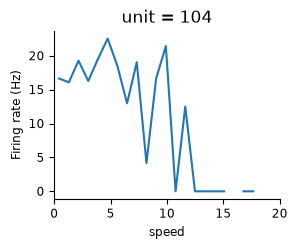

In [65]:
tuning_speed=nap.compute_tuning_curves(data=spikes_loom, features=speed_tsd, bins=21,epochs=loom_trials,feature_names=["speed"])
fig = plt.figure()
plt.subplot(221)
tuning_speed[0].plot()
# plt.plot(tuning_curves[0])
plt.ylabel("Firing rate (Hz)")
plt.xlim(0,20)

In [66]:
decoded, proba_feature=nap.decode_bayes(tuning_curves=tuning_speed,data=spikes_loom,epochs=loom_trials,bin_size=0.1)

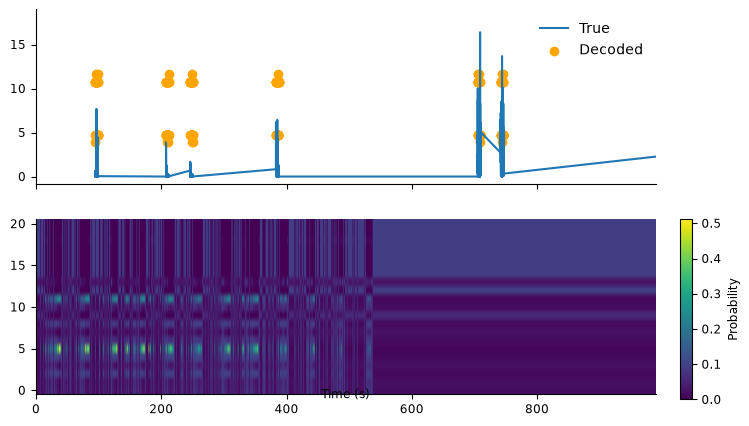

In [67]:
fig, (ax1, ax2) = plt.subplots(figsize=(8, 5), nrows=2, ncols=1, sharex=True)
feature=speed_tsd.restrict(loom_trials)
ax1.plot(
    feature.times(),
    feature.values,
    label="True",
)
ax1.scatter(
    decoded.times(),
    decoded.values,
    label="Decoded",
    c="orange",
)
ax1.legend(
    frameon=False,
    bbox_to_anchor=(1.0, 1.0),
)
im = ax2.imshow(proba_feature.values.T, aspect="auto", origin="lower", cmap="viridis")
cbar_ax = fig.add_axes([0.93, 0.1, 0.015, 0.36])
fig.colorbar(im, cax=cbar_ax, label="Probability")
ax2.set_xlabel("Time (s)", labelpad=-20)
plt.show()

In [68]:
nonloom_trials=ep[ep['looming_boolean']==0]
spikes_nonloom=spikes_interest.restrict(nonloom_trials)

(0.0, 20.0)

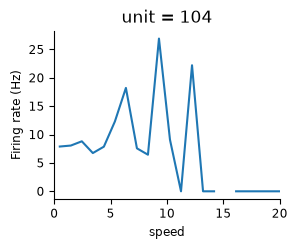

In [69]:
tuning_speed=nap.compute_tuning_curves(data=spikes_nonloom, features=speed_tsd, bins=21,epochs=nonloom_trials,feature_names=["speed"])
fig = plt.figure()
plt.subplot(221)
tuning_speed[0].plot()
plt.ylabel("Firing rate (Hz)")
plt.xlim(0,20)

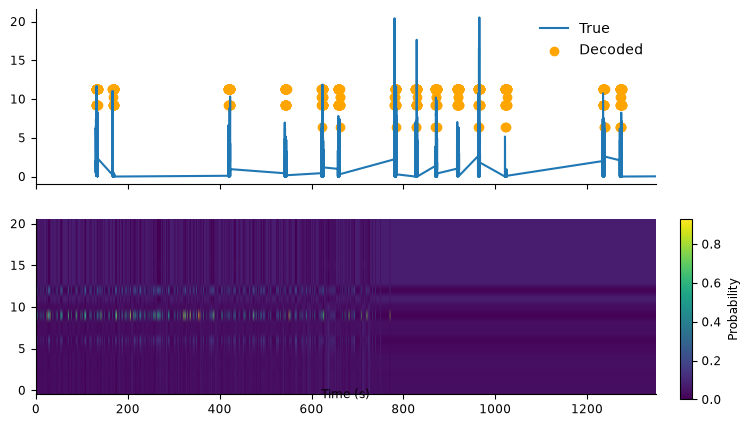

In [70]:
decoded, proba_feature=nap.decode_bayes(tuning_curves=tuning_speed,data=spikes_nonloom,epochs=nonloom_trials,bin_size=0.1)
fig, (ax1, ax2) = plt.subplots(figsize=(8, 5), nrows=2, ncols=1, sharex=True)
feature=speed_tsd.restrict(nonloom_trials)
ax1.plot(
    feature.times(),
    feature.values,
    label="True",
)
ax1.scatter(
    decoded.times(),
    decoded.values,
    label="Decoded",
    c="orange",
)
ax1.legend(
    frameon=False,
    bbox_to_anchor=(1.0, 1.0),
)
im = ax2.imshow(proba_feature.values.T, aspect="auto", origin="lower", cmap="viridis")
cbar_ax = fig.add_axes([0.93, 0.1, 0.015, 0.36])
fig.colorbar(im, cax=cbar_ax, label="Probability")
ax2.set_xlabel("Time (s)", labelpad=-20)
plt.show()

(0.0, 20.0)

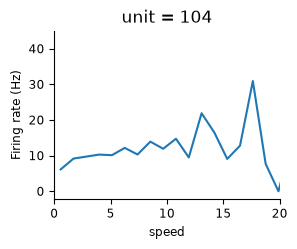

In [41]:
fig = plt.figure()
plt.subplot(221)
tuning_speed[0].plot()
# plt.plot(tuning_curves[0])
plt.ylabel("Firing rate (Hz)")
plt.xlim(0,20)

In [37]:
#prediction, probs_speed= nap.decode_bayes(tuning_curves=tuning_speed,data=spikes_interest,epochs=ep,bin_size=0.1)
prediction, probs_speed= nap.decode_bayes(tuning_curves=tuning_speed,data=spikes_interest,epochs=ep,bin_size=0.1)

In [30]:
tuning_ry=nap.compute_tuning_curves(data=spikes_interest, features=ry_tsd, bins=61,epochs=ry_tsd.time_support,feature_names=["angular velocity"])